In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src import config


In [2]:
from src.dataset import BioHubDataset
from src.detector import CellDetector
from src.tracker import HungarianTracker


In [3]:
DATASET = BioHubDataset(config.DATASET_PATH)

sample = DATASET.train_samples[0]

volume = DATASET.load_volume(sample)


In [4]:
detector = CellDetector(
    sigma=2,
    threshold_abs=1800,
    min_distance=12,
)

detections = detector.detect_volume(volume)

In [5]:
tracker = HungarianTracker(
    max_distance=25
)

tracks = tracker.track(detections)

print(len(tracks))

print(tracks[0][:5])

99
[{'previous': np.int64(0), 'current': np.int64(2), 'distance': np.float64(5.0)}, {'previous': np.int64(2), 'current': np.int64(4), 'distance': np.float64(1.4142135623730951)}, {'previous': np.int64(3), 'current': np.int64(16), 'distance': np.float64(5.656854249492381)}, {'previous': np.int64(4), 'current': np.int64(3), 'distance': np.float64(3.605551275463989)}, {'previous': np.int64(6), 'current': np.int64(5), 'distance': np.float64(2.0)}]


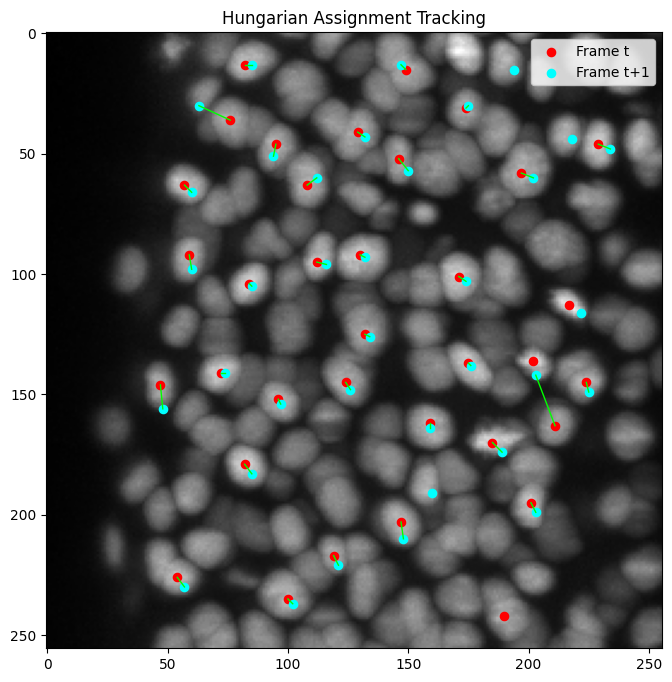

In [6]:
import matplotlib.pyplot as plt

frame = 0

img = np.array(volume[frame]).max(axis=0)

previous = detections[frame]
current = detections[frame + 1]

matches = tracks[frame]

plt.figure(figsize=(8,8))

plt.imshow(img, cmap="gray")

# Previous detections (red)
plt.scatter(
    previous[:,1],
    previous[:,0],
    c="red",
    s=35,
    label="Frame t",
)

# Current detections (cyan)
plt.scatter(
    current[:,1],
    current[:,0],
    c="cyan",
    s=35,
    label="Frame t+1",
)

# Draw matches
for m in matches:

    p1 = previous[m["previous"]]
    p2 = current[m["current"]]

    plt.plot(
        [p1[1], p2[1]],
        [p1[0], p2[0]],
        color="lime",
        linewidth=1,
    )

plt.legend()
plt.title("Hungarian Assignment Tracking")
plt.show()